In diesem Notebook möchte ich die Gesichtserkennung mit Facenet512 (euclidean_l2) und GPT-4o evaluieren.

Dafür laden wir einen Datensatz aus [dem ursprünglichen Notebook](# REMOVED: Colab link (run notebook locally))

Im obigen Notebook haben wir auch den Threshold optimiert: `0.9410000000000002`

Datensatz mit Gesichtserkennung: `2024-07-03-Faces-in-Posts-unfiltered.csv`

## Vorbereitung Datensatz

In [ ]:
import pandas as pd

df = pd.read_csv('../data/2024-07-03-Faces-in-Posts-unfiltered.csv')

In [ ]:
df = df.groupby('filename').agg({
    'Ground Truth': lambda x: ', '.join(set(x)),
    'Model': lambda x: ', '.join(set(x)),
    'account_name': 'first',
    'match_score': 'first'
    }).reset_index()

df.rename(columns={'Model': 'FaceNet', 'match_score': 'FaceNet Score'}, inplace=True)

In [ ]:
df.head()

,filename,Ground Truth,FaceNet,account_name,FaceNet Score
0,abaerbock/2021-09-13_14-02-02_UTC.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.466279
1,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,"Unknown, Annalena Baerbock",Unknown,abaerbock,NaN
2,abaerbock/2021-09-13_19-36-55_UTC_2.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.566867
3,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,"Unknown, Annalena Baerbock",Unknown,abaerbock,NaN
4,abaerbock/2021-09-13_19-36-55_UTC_4.jpg,"Unknown, Annalena Baerbock","Unknown, Annalena Baerbock",abaerbock,0.540131


In [ ]:
filtered_df = pd.read_csv('../data/2024-09-09-Filtered-Posts-Front-Runners.csv')

In [ ]:
filtered_df.head()

,image,shortcode,username
0,armin_laschet/2021-09-22_14-55-06_UTC_2.jpg,CUIMVtAIcv0,armin_laschet
1,armin_laschet/2021-09-18_19-12-07_UTC_5.jpg,CT-Wks4orcn,armin_laschet
2,armin_laschet/2021-09-15_12-38-48_UTC.jpg,CT17LV3ohf5,armin_laschet
3,armin_laschet/2021-09-21_11-03-21_UTC_1.jpg,CUFNBhQIo6x,armin_laschet
4,armin_laschet/2021-09-23_13-50-48_UTC_1.jpg,CUKpxsNIuW2,armin_laschet


In [ ]:
df = df[df['filename'].isin(filtered_df['image'])]

In [ ]:
def extract_candidate(row):
  names = row['Ground Truth'].split(', ')
  for name in names:
    if name != "Unknown":
      return name
  return "Unknown"

df['Candidate'] = df.apply(extract_candidate, axis=1)

In [ ]:
accounts_dict = {
  "armin_laschet": ["Armin Laschet"],
  "spdde": ["Olaf Scholz"],
  "christianlindner": ["Christian Lindner"],
  "abaerbock": ["Annalena Baerbock"],
  "cdu": ["Armin Laschet"],
  "olafscholz": ["Olaf Scholz"],
  "die_gruenen": ["Annalena Baerbock"],
  "christlichsozialeunion": ["Markus Söder"],
  "fdp": ["Christian Lindner"],
  "markus.soeder":  ["Markus Söder"],
}

party_dict = {
  "armin_laschet": "CDU",
  "spdde": "SPD",
  "christianlindner": "FDP",
  "abaerbock": "Die Grünen",
  "cdu": "CDU",
  "olafscholz": "SPD",
  "die_gruenen": "Die Grünen",
  "christlichsozialeunion": "CSU",
  "fdp": "FDP",
  "markus.soeder":  "CSU",
}

## Interrater Agreement

In [ ]:
import pandas as pd

annotations = pd.read_csv('../data/2024-07-12-Annotations-Posts-Faces-wo-review.csv')

In [ ]:
annotations['filename'] = annotations['filename'].apply(lambda x: x.replace('../data/', ''))

In [ ]:
annotations.head()

,uuid,filename,7107,17607,20479,20817
0,b248b1d2-1780-4b4c-8529-571b0246a9e5,olafscholz/2021-09-13_07-45-59_UTC.jpg,"Unknown, Olaf Scholz","Unknown, Olaf Scholz",NaN,NaN
1,d83b5202-1f81-4b16-b8c8-360f0e6051e5,olafscholz/2021-09-14_10-23-23_UTC_1.jpg,Unknown,Unknown,NaN,NaN
2,95c9174b-5389-4ccb-89ac-98de4be55d9e,olafscholz/2021-09-14_10-23-23_UTC_1.jpg,"Unknown, Olaf Scholz","Unknown, Olaf Scholz",NaN,NaN
3,2d573a4a-21f5-464f-aef4-8700597752c1,olafscholz/2021-09-17_10-42-46_UTC_2.jpg,NaN,Unknown,Unknown,NaN
4,3539ae42-9adf-4733-a703-024b662d8eff,olafscholz/2021-09-17_10-42-46_UTC_2.jpg,NaN,Unknown,Unknown,NaN


In [ ]:
import pandas as pd
import numpy as np

# Helper function to clean and join sets of strings
def clean_and_join(series):
    try:
        # Convert each entry to a set of strings
        split_sets = series.apply(lambda x: set(str(x).split(', ')))
        # Join all sets into one
        combined_set = set.union(*split_sets)
        # Join the set back into a single string
        return ', '.join(combined_set)
    except Exception as e:
        print(f"Error processing series: {e}")
        return ''

annotations.fillna('', inplace=True)
annotations = annotations.groupby('filename').agg({
    '7107': clean_and_join,
    '17607': clean_and_join,
    '20479': clean_and_join,
    '20817': clean_and_join,
    #'21123': clean_and_join,
}).reset_index()
annotations.replace('', np.nan, inplace=True)

In [ ]:
def extract_username(row):
  username = row['filename'].split('/')[0]
  if username == "armin":
    return "armin_laschet"
  elif username == "die_gruenen":
    return "die_gruenen"

  return username

annotations['username'] = annotations.apply(extract_username, axis=1)

In [ ]:
import numpy as np

def filter_candidates(row, column_name):
    names = row[column_name]
    if not pd.isna(names):
      names = names.split(', ')
      names = set(names)
      for name in names:
        if name in accounts_dict.get(row['username'], []):
          return name
      return "Unknown"

    return np.nan

# Example usage for multiple columns
columns_to_filter = ['7107', "17607", "20479", "20817"] #, '21123']
for col in columns_to_filter:
    annotations[col] = annotations.apply(filter_candidates, axis=1, column_name=col)

In [ ]:
annotations['Annotation Count'] = annotations[['7107', '17607', '20479', '20817']].notna().sum(axis=1)

In [ ]:
annotations

,filename,7107,17607,20479,20817,username,Annotation Count
0,abaerbock/2021-09-13_14-02-02_UTC.jpg,NaN,NaN,NaN,Annalena Baerbock,abaerbock,1
1,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,NaN,Annalena Baerbock,NaN,NaN,abaerbock,1
2,abaerbock/2021-09-13_19-36-55_UTC_2.jpg,Annalena Baerbock,NaN,NaN,NaN,abaerbock,1
3,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,NaN,NaN,NaN,Annalena Baerbock,abaerbock,1
4,abaerbock/2021-09-13_19-36-55_UTC_4.jpg,Annalena Baerbock,NaN,NaN,NaN,abaerbock,1
...,...,...,...,...,...,...,...
1006,susanne_hennig_wellsow/2021-09-24_17-21-09_UTC...,NaN,Unknown,Unknown,NaN,susanne_hennig_wellsow,2
1007,susanne_hennig_wellsow/2021-09-25_17-31-57_UTC...,NaN,Unknown,Unknown,NaN,susanne_hennig_wellsow,2
1008,susanne_hennig_wellsow/2021-09-25_17-31-57_UTC...,NaN,Unknown,Unknown,NaN,susanne_hennig_wellsow,2
1009,susanne_hennig_wellsow/2021-09-25_17-31-57_UTC...,NaN,Unknown,Unknown,NaN,susanne_hennig_wellsow,2


Wir haben nicht für alle Bilder mehrere Annotationen. Deshalb nehmen wir die, die wir haben und samplen daraus ein 30% overlap sample. Das kann man besser argumentieren.

In [ ]:
filtered_annotations = annotations[annotations['filename'].isin(df['filename'])]

In [ ]:
filtered_annotations = filtered_annotations[filtered_annotations['Annotation Count'] > 1]

In [ ]:
filtered_annotations = filtered_annotations.sample((int(735*0.3)))

In [ ]:
filtered_annotations.to_csv('../data/2024-07-12-Post-Images-wo-Review-30p-overlap-sample.csv', index=False)

In [ ]:
filtered_annotations = pd.read_csv('/content/2024-07-12-Post-Images-wo-Review-30p-overlap-sample (1).csv')

In [ ]:
len(filtered_annotations)

220

Merge with the overall dataframe

In [ ]:
df = pd.merge(df, filtered_annotations, on='filename', how='right')

In [ ]:
df.head()

,filename,Ground Truth,FaceNet,account_name,FaceNet Score,Candidate,7107,17607,20479,20817,username,Annotation Count
0,cdu/2021-09-16_17-02-39_UTC_1.jpg,"Armin Laschet, Unknown","Armin Laschet, Unknown",cdu,0.671931,Armin Laschet,Armin Laschet,Armin Laschet,NaN,NaN,cdu,2
1,olafscholz/2021-09-16_19-01-33_UTC_1.jpg,"Unknown, Olaf Scholz","Unknown, Olaf Scholz",olafscholz,0.672295,Olaf Scholz,NaN,Olaf Scholz,Olaf Scholz,NaN,olafscholz,2
2,cdu/2021-09-18_13-19-15_UTC_6.jpg,Unknown,Unknown,cdu,NaN,Unknown,NaN,Unknown,Unknown,NaN,cdu,2
3,cdu/2021-09-23_16-10-56_UTC_3.jpg,"Armin Laschet, Unknown","Armin Laschet, Unknown",cdu,0.642328,Armin Laschet,NaN,Armin Laschet,Armin Laschet,NaN,cdu,2
4,olafscholz/2021-09-14_10-23-23_UTC_1.jpg,"Unknown, Olaf Scholz","Unknown, Olaf Scholz",olafscholz,0.547668,Olaf Scholz,Olaf Scholz,Olaf Scholz,NaN,NaN,olafscholz,2


In [ ]:
!pip install -q krippendorff

In [ ]:
import krippendorff
import pandas as pd

def convert_to_reliability_data(matrix):
    transposed_matrix = matrix.T
    reliability_data = []
    for _, ratings in transposed_matrix.iterrows():
        reliability_data.append(ratings.tolist())
    return reliability_data

# We use df here, as we are only intersted in a set of parties already defined in df.
test_data = df[['7107', "17607", "20479", "20817"]] #, "21123"]]
reliability_data = convert_to_reliability_data(test_data)   # contingency_matrix)

# Calculating Krippendorff's Alpha treating "Unsure" as a distinct category
alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement='nominal')

print("Krippendorff's Alpha:", alpha)

Krippendorff's Alpha: 0.944844915586965


## Evaluation FaceNet

In [ ]:
def extract_candidate_model(row):
  names = row['FaceNet'].split(', ')
  for name in names:
    if name != "Unknown" and row['FaceNet Score'] < .9410000000000002:
      return name
  return "Unknown"

df['Candidate FaceNet'] = df.apply(extract_candidate_model, axis=1)

In [ ]:
df.head()

,filename,Ground Truth,FaceNet,account_name,FaceNet Score,Candidate,7107,17607,20479,20817,username,Annotation Count,Candidate FaceNet
0,abaerbock/2021-09-13_14-02-02_UTC.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.466279,Annalena Baerbock,NaN,NaN,NaN,NaN,NaN,NaN,Annalena Baerbock
1,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,"Unknown, Annalena Baerbock",Unknown,abaerbock,NaN,Annalena Baerbock,NaN,NaN,NaN,NaN,NaN,NaN,Unknown
2,abaerbock/2021-09-13_19-36-55_UTC_2.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.566867,Annalena Baerbock,NaN,NaN,NaN,NaN,NaN,NaN,Annalena Baerbock
3,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,"Unknown, Annalena Baerbock",Unknown,abaerbock,NaN,Annalena Baerbock,NaN,NaN,NaN,NaN,NaN,NaN,Unknown
4,abaerbock/2021-09-13_19-36-55_UTC_4.jpg,"Unknown, Annalena Baerbock","Unknown, Annalena Baerbock",abaerbock,0.540131,Annalena Baerbock,NaN,NaN,NaN,NaN,NaN,NaN,Annalena Baerbock


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(df['Candidate'], df['Candidate FaceNet']))

                   precision    recall  f1-score   support

Annalena Baerbock       0.92      0.76      0.83        59
    Armin Laschet       0.99      0.79      0.88       177
Christian Lindner       1.00      0.71      0.83        55
     Markus Söder       1.00      0.87      0.93        87
      Olaf Scholz       0.99      0.87      0.93        79
          Unknown       0.73      0.98      0.84       251

         accuracy                           0.87       708
        macro avg       0.94      0.83      0.87       708
     weighted avg       0.90      0.87      0.87       708



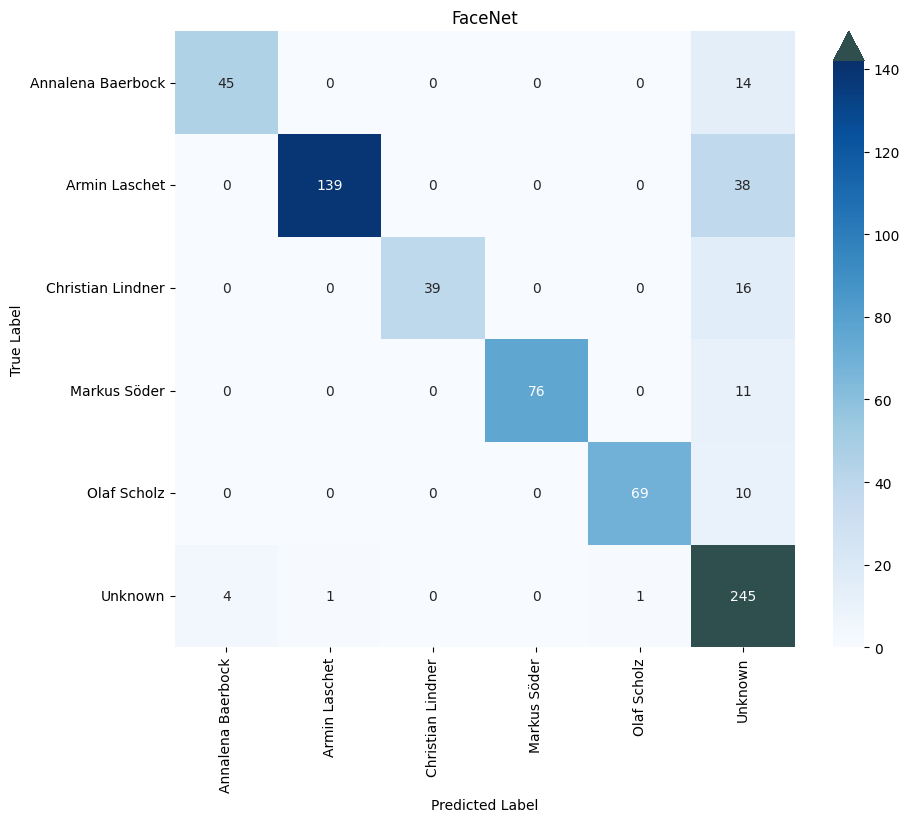

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# Assuming 'df' is your DataFrame
labels = ['Annalena Baerbock', 'Armin Laschet',
          'Christian Lindner', 'Markus Söder', 'Olaf Scholz',  'Unknown']

# Generate the confusion matrix
cm = confusion_matrix(df['Candidate'], df['Candidate FaceNet'], labels=labels)

# Find the maximum value in the confusion matrix
max_value = 142

# Create a custom colormap
custom_cmap = sns.color_palette("Blues", as_cmap=True)
custom_cmap.set_over('darkslategray')  # Set the color for values above the maximum to red

# Plotting the confusion matrix with the custom colormap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap=custom_cmap, xticklabels=labels, yticklabels=labels, vmax=max_value, cbar_kws={'extend': 'max'})
plt.title('FaceNet')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [ ]:
import krippendorff
import pandas as pd

def convert_to_reliability_data(matrix):
    transposed_matrix = matrix.T
    reliability_data = []
    for _, ratings in transposed_matrix.iterrows():
        reliability_data.append(ratings.tolist())
    return reliability_data

# We use df here, as we are only intersted in a set of parties already defined in df.
test_data = df[['7107', "17607", "20479", "20817", 'Candidate FaceNet']]
reliability_data = convert_to_reliability_data(test_data)   # contingency_matrix)

# Calculating Krippendorff's Alpha treating "Unsure" as a distinct category
alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement='nominal')

print("Krippendorff's Alpha:", alpha)

Krippendorff's Alpha: 0.8393902889094694


In [ ]:
#@title Qualitative Inspection
#@markdown Run this cell to generate a table comparing the Human and Model classifications.

import json
from google.cloud import storage
from google.oauth2 import service_account
from datetime import timedelta, datetime
import pandas as pd
from IPython.display import display, HTML

images_per_label = 9  # @param {type: "slider", min: 1, max: 200}
credentials_file = "# REMOVED: GCP service account key not needed for local execution" # @param {type: "string"}


# Assuming df is your DataFrame, you need to have it loaded already.
# Group the DataFrame by 'Majority Decision'
filtered = df[df['Candidate'] != df['Candidate FaceNet']].copy()

# Load the credentials from the JSON file
with open(credentials_file, 'r') as f:
    credentials_info = json.load(f)

# Create credentials object from the service account information
credentials = service_account.Credentials.from_service_account_info(credentials_info)

# Create a storage client object using the credentials
storage_client = storage.Client(credentials=credentials)

# Set the expiration time to 7 days from now
expiration_time = timedelta(days=7)

# Iterate through the rows in the DataFrame and sign the URLs
for index, row in filtered.iterrows():
    # Split the gcloud URL to get bucket name and blob name
    bucket_name = "ig-politik-posts"
    blob_name = row['filename']

    # Get the bucket and blob objects
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(blob_name)

    # Generate the signed URL, passing the expiration time
    url = blob.generate_signed_url(expiration=datetime.utcnow() + expiration_time)
    filtered.loc[index, 'gcloud'] = url

grouped = filtered.groupby('Candidate')

# HTML template with Bootstrap
html_template = '''
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no">
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.3/dist/css/bootstrap.min.css" rel="stylesheet">
    <style>
        @media print {{
            .page-break {{ page-break-before: always; }}
        }}
        .card img {{
            object-fit: cover;
        }}
    </style>
    <title>Grouped Images</title>
</head>
<body>
    <div class="container">
        <h1>Qualitative Inspection</h1>
        {content}
    </div>
    <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.3.3/dist/js/bootstrap.bundle.min.js"></script>
</body>
</html>
'''

# Generating the content for each group
content = ''
card_count = 0
for decision, group in grouped:
    if images_per_label >= len(group):
        sample_size = len(group)
    else:
        sample_size = images_per_label

    sample = group.sample(sample_size)
    content += f'<h2>{decision}</h2>'
    content += '<div class="row">'
    for _, row in sample.iterrows():
        content += f'''
        <div class="col-md-4">
            <div class="card mb-4 shadow-sm">
                <img src="{row['gcloud']}" class="card-img-top" alt="{row['filename']}">
                <div class="card-body">
                    <p class="card-text">{row['filename']}</p>
                    <p class="card-text">FaceNet: {row['Candidate FaceNet']}</p>
                    <p class="card-text">Humans: {row['Candidate']}</p>
                </div>
            </div>
        </div>
        '''
        card_count += 1
        if card_count % 6 == 0:
            content += '</div><div class="page-break"></div><div class="row">'
    content += '</div>'

# Combine the content with the HTML template
html_output = html_template.format(content=content)

# Write the HTML to a file
with open('grouped_images_facenet.html', 'w') as file:
    file.write(html_output)

print("HTML file 'grouped_images_facenet.html' has been created.")

# Function to display the HTML in Colab
def display_html(file_path):
    with open(file_path, 'r') as file:
        html_content = file.read()
    display(HTML(html_content))

# Display the HTML file in the notebook
display_html('grouped_images_facenet.html')

HTML file 'grouped_images_facenet.html' has been created.


## Evaluation GPT-4o

In [ ]:
gpt_df = pd.read_csv('../data/2024-07-03-Faces-in-Posts-GPT.csv')

In [ ]:
gpt_df['GPT'] = gpt_df['GPT'].apply(lambda x: x.replace("['", ""))
gpt_df['GPT'] = gpt_df['GPT'].apply(lambda x: x.replace("']", ""))

In [ ]:
gpt_df['GPT'] = gpt_df['GPT'].apply(lambda x: False if x == "Unsure" or x == "False" else True)

In [ ]:
def extract_candidate_gpt(row):
  if row['GPT'] == True:
    return accounts_dict[row['account_name']][0]
  else:
    return "Unknown"

gpt_df['Candidate GPT'] = gpt_df.apply(extract_candidate_gpt, axis=1)

In [ ]:
df = pd.merge(df, gpt_df[['filename', 'Candidate GPT']], on='filename', how='left')

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(df['Candidate'], df['Candidate GPT']))

                   precision    recall  f1-score   support

Annalena Baerbock       0.89      0.83      0.86        59
    Armin Laschet       0.97      0.98      0.97       177
Christian Lindner       0.92      0.87      0.90        55
     Markus Söder       0.96      0.92      0.94        87
      Olaf Scholz       0.89      0.91      0.90        79
          Unknown       0.86      0.89      0.88       251

         accuracy                           0.91       708
        macro avg       0.92      0.90      0.91       708
     weighted avg       0.91      0.91      0.91       708



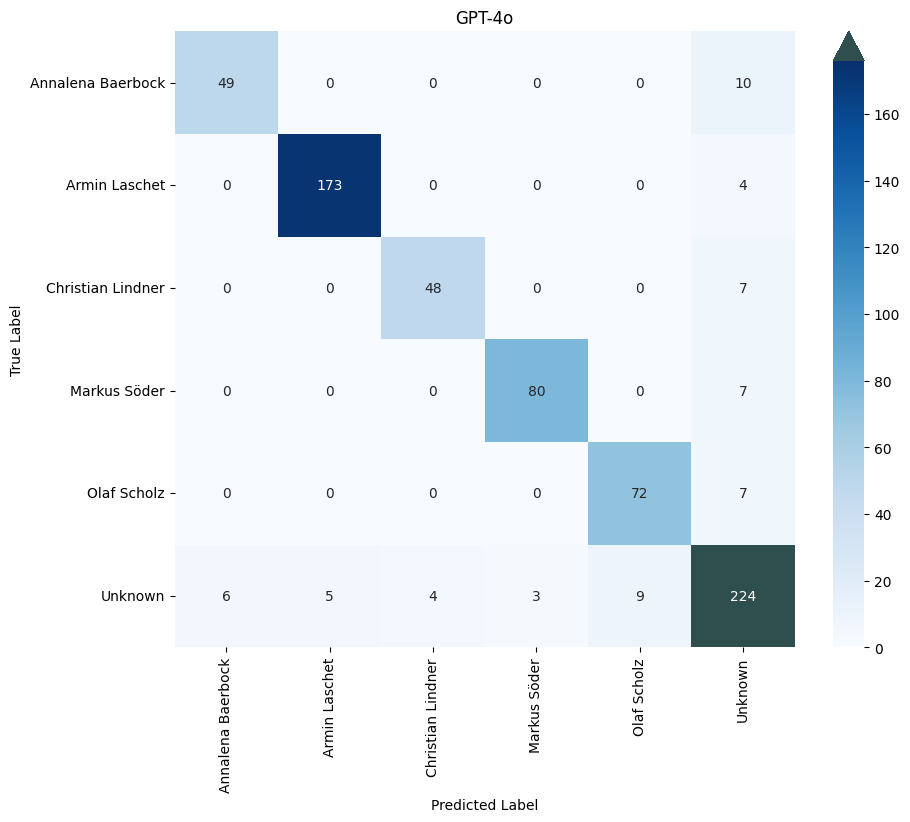

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# Assuming 'df' is your DataFrame
labels = ['Annalena Baerbock', 'Armin Laschet',
          'Christian Lindner', 'Markus Söder', 'Olaf Scholz',  'Unknown']

# Generate the confusion matrix
cm = confusion_matrix(df['Candidate'], df['Candidate GPT'], labels=labels)

# Find the maximum value in the confusion matrix
max_value = 176

# Create a custom colormap
custom_cmap = sns.color_palette("Blues", as_cmap=True)
custom_cmap.set_over('darkslategray')  # Set the color for values above the maximum to red

# Plotting the confusion matrix with the custom colormap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap=custom_cmap, xticklabels=labels, yticklabels=labels, vmax=max_value, cbar_kws={'extend': 'max'})
plt.title('GPT-4o')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [ ]:
import krippendorff
import pandas as pd

def convert_to_reliability_data(matrix):
    transposed_matrix = matrix.T
    reliability_data = []
    for _, ratings in transposed_matrix.iterrows():
        reliability_data.append(ratings.tolist())
    return reliability_data

# We use df here, as we are only intersted in a set of parties already defined in df.
test_data = df[['7107', "17607", "20479", "20817", 'Candidate GPT']]
reliability_data = convert_to_reliability_data(test_data)   # contingency_matrix)

# Calculating Krippendorff's Alpha treating "Unsure" as a distinct category
alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement='nominal')

print("Krippendorff's Alpha:", alpha)

Krippendorff's Alpha: 0.8986472788283407


In [ ]:
df[df['Candidate'] != df['Candidate GPT']]

,filename,Ground Truth,FaceNet,account_name,FaceNet Score,Candidate,7107,17607,20479,20817,username,Annotation Count,Candidate FaceNet,Candidate GPT
1,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,"Unknown, Annalena Baerbock",Unknown,abaerbock,NaN,Annalena Baerbock,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown
5,abaerbock/2021-09-14_10-00-20_UTC_1.jpg,Unknown,"Unknown, Annalena Baerbock",abaerbock,0.725651,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,Annalena Baerbock,Annalena Baerbock
9,abaerbock/2021-09-14_10-00-20_UTC_6.jpg,Unknown,Unknown,abaerbock,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,Annalena Baerbock
10,abaerbock/2021-09-14_15-44-32_UTC.jpg,Unknown,Annalena Baerbock,abaerbock,0.510233,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,Annalena Baerbock,Annalena Baerbock
18,abaerbock/2021-09-17_11-48-57_UTC.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.539119,Annalena Baerbock,NaN,NaN,NaN,NaN,NaN,NaN,Annalena Baerbock,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
657,spdde/2021-09-16_16-07-38_UTC.jpg,Unknown,Unknown,spdde,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,Olaf Scholz
662,spdde/2021-09-18_12-09-36_UTC.jpg,Olaf Scholz,Olaf Scholz,spdde,0.432452,Olaf Scholz,NaN,Olaf Scholz,Olaf Scholz,NaN,spdde,2.0,Olaf Scholz,Unknown
663,spdde/2021-09-18_14-42-04_UTC_1.jpg,Unknown,Unknown,spdde,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,Olaf Scholz
668,spdde/2021-09-18_14-42-04_UTC_6.jpg,Unknown,Olaf Scholz,spdde,1.028462,Unknown,NaN,Unknown,Unknown,NaN,spdde,2.0,Unknown,Olaf Scholz


In [ ]:
#@title Qualitative Inspection
#@markdown Run this cell to generate a table comparing the Human and Model classifications.
images_per_label = 9  # @param {type: "slider", min: 1, max: 200}
credentials_file = "# REMOVED: GCP service account key not needed for local execution" # @param {type: "string"}


import json
from google.cloud import storage
from google.oauth2 import service_account
from datetime import timedelta, datetime
import pandas as pd
from IPython.display import display, HTML

# Assuming df is your DataFrame, you need to have it loaded already.
# Group the DataFrame by 'Majority Decision'
filtered = df[df['Candidate'] != df['Candidate GPT']].copy()

# Load the credentials from the JSON file
with open(credentials_file, 'r') as f:
    credentials_info = json.load(f)

# Create credentials object from the service account information
credentials = service_account.Credentials.from_service_account_info(credentials_info)

# Create a storage client object using the credentials
storage_client = storage.Client(credentials=credentials)

# Set the expiration time to 7 days from now
expiration_time = timedelta(days=7)

# Iterate through the rows in the DataFrame and sign the URLs
for index, row in filtered.iterrows():
    # Split the gcloud URL to get bucket name and blob name
    bucket_name = "ig-politik-posts"
    blob_name = row['filename']

    # Get the bucket and blob objects
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(blob_name)

    # Generate the signed URL, passing the expiration time
    url = blob.generate_signed_url(expiration=datetime.utcnow() + expiration_time)
    filtered.loc[index, 'gcloud'] = url

grouped = filtered.groupby('Candidate')

# HTML template with Bootstrap
html_template = '''
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no">
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.3/dist/css/bootstrap.min.css" rel="stylesheet">
    <style>
        @media print {{
            .page-break {{ page-break-before: always; }}
        }}
        .card img {{
            object-fit: cover;
        }}
    </style>
    <title>Grouped Images</title>
</head>
<body>
    <div class="container">
        <h1>Qualitative Inspection</h1>
        {content}
    </div>
    <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.3.3/dist/js/bootstrap.bundle.min.js"></script>
</body>
</html>
'''

# Generating the content for each group
content = ''
card_count = 0
for decision, group in grouped:
    if images_per_label >= len(group):
        sample_size = len(group)
    else:
        sample_size = images_per_label

    sample = group.sample(sample_size)
    content += f'<h2>{decision}</h2>'
    content += '<div class="row">'
    for _, row in sample.iterrows():
        content += f'''
        <div class="col-md-4">
            <div class="card mb-4 shadow-sm">
                <img src="{row['gcloud']}" class="card-img-top" alt="{row['filename']}">
                <div class="card-body">
                    <p class="card-text">{row['filename']}</p>
                    <p class="card-text">GPT-4o: {row['Candidate GPT']}</p>
                    <p class="card-text">Humans: {row['Candidate']}</p>
                </div>
            </div>
        </div>
        '''
        card_count += 1
        if card_count % 6 == 0:
            content += '</div><div class="page-break"></div><div class="row">'
    content += '</div>'

# Combine the content with the HTML template
html_output = html_template.format(content=content)

# Write the HTML to a file
with open('grouped_images_gpt.html', 'w') as file:
    file.write(html_output)

print("HTML file 'grouped_images_facenet.html' has been created.")

# Function to display the HTML in Colab
def display_html(file_path):
    with open(file_path, 'r') as file:
        html_content = file.read()
    display(HTML(html_content))

# Display the HTML file in the notebook
display_html('grouped_images_gpt.html')

HTML file 'grouped_images_facenet.html' has been created.


In [ ]:
gpt_df

,Unnamed: 0,filename,Ground Truth,Model,account_name,GPT,GPT Comment,Candidate GPT
0,0,abaerbock/2021-09-13_14-02-02_UTC.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,True,NaN,Annalena Baerbock
1,1,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,"Unknown, Annalena Baerbock",Unknown,abaerbock,False,The image does not provide enough information ...,Unknown
2,2,abaerbock/2021-09-13_19-36-55_UTC_2.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,True,NaN,Annalena Baerbock
3,3,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,"Unknown, Annalena Baerbock",Unknown,abaerbock,True,NaN,Annalena Baerbock
4,4,abaerbock/2021-09-13_19-36-55_UTC_4.jpg,"Unknown, Annalena Baerbock","Unknown, Annalena Baerbock",abaerbock,True,The image shows a person speaking at an event ...,Annalena Baerbock
...,...,...,...,...,...,...,...,...
730,730,spdde/2021-09-24_20-19-17_UTC_3.jpg,Unknown,Unknown,spdde,True,The image contains signs with the name 'Scholz...,Olaf Scholz
731,731,spdde/2021-09-24_20-19-17_UTC_4.jpg,"Olaf Scholz, Unknown","Olaf Scholz, Unknown",spdde,True,NaN,Olaf Scholz
732,732,spdde/2021-09-25_10-04-18_UTC.jpg,Unknown,"Olaf Scholz, Unknown",spdde,False,"The image shows a person speaking at a rally, ...",Unknown
733,733,spdde/2021-09-25_11-23-57_UTC.jpg,Unknown,Unknown,spdde,False,NaN,Unknown


## Check Differences

In [ ]:
df[(df['Candidate GPT'] != df['Candidate FaceNet']) & (df['Candidate'] != "Unknown")][['filename', 'Candidate', 'Candidate FaceNet', 'Candidate GPT']]

,filename,Candidate,Candidate FaceNet,Candidate GPT
3,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,Annalena Baerbock,Unknown,Annalena Baerbock
6,abaerbock/2021-09-14_10-00-20_UTC_3.jpg,Annalena Baerbock,Unknown,Annalena Baerbock
11,abaerbock/2021-09-15_13-20-23_UTC_1.jpg,Annalena Baerbock,Unknown,Annalena Baerbock
18,abaerbock/2021-09-17_11-48-57_UTC.jpg,Annalena Baerbock,Annalena Baerbock,Unknown
23,abaerbock/2021-09-17_19-48-04_UTC_4.jpg,Annalena Baerbock,Unknown,Annalena Baerbock
...,...,...,...,...
662,spdde/2021-09-18_12-09-36_UTC.jpg,Olaf Scholz,Olaf Scholz,Unknown
671,spdde/2021-09-18_14-42-04_UTC_9.jpg,Olaf Scholz,Unknown,Olaf Scholz
678,spdde/2021-09-20_15-56-40_UTC.jpg,Olaf Scholz,Unknown,Olaf Scholz
687,spdde/2021-09-22_18-00-38_UTC_3.jpg,Olaf Scholz,Unknown,Olaf Scholz


In [ ]:
#@title Qualitative Inspection
#@markdown Run this cell to generate a table comparing the Human and Model classifications.
images_per_label = 200  # @param {type: "slider", min: 1, max: 200}
credentials_file = "# REMOVED: GCP service account key not needed for local execution" # @param {type: "string"}


import json
from google.cloud import storage
from google.oauth2 import service_account
from datetime import timedelta, datetime
import pandas as pd
from IPython.display import display, HTML

# Assuming df is your DataFrame, you need to have it loaded already.
# Group the DataFrame by 'Majority Decision'
filtered = df[(df['Candidate FaceNet'] == df['Candidate GPT']) & (df['Candidate FaceNet'] == "Unknown")].copy()


# Load the credentials from the JSON file
with open(credentials_file, 'r') as f:
    credentials_info = json.load(f)

# Create credentials object from the service account information
credentials = service_account.Credentials.from_service_account_info(credentials_info)

# Create a storage client object using the credentials
storage_client = storage.Client(credentials=credentials)

# Set the expiration time to 7 days from now
expiration_time = timedelta(days=7)

# Iterate through the rows in the DataFrame and sign the URLs
for index, row in filtered.iterrows():
    # Split the gcloud URL to get bucket name and blob name
    bucket_name = "ig-politik-posts"
    blob_name = row['filename']

    # Get the bucket and blob objects
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(blob_name)

    # Generate the signed URL, passing the expiration time
    url = blob.generate_signed_url(expiration=datetime.utcnow() + expiration_time)
    filtered.loc[index, 'gcloud'] = url

grouped = filtered.groupby('Candidate')

# HTML template with Bootstrap
html_template = '''
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no">
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.3/dist/css/bootstrap.min.css" rel="stylesheet">
    <style>
        @media print {{
            .page-break {{ page-break-before: always; }}
        }}
        .card img {{
            object-fit: cover;
        }}
    </style>
    <title>Grouped Images</title>
</head>
<body>
    <div class="container">
        <h1>Qualitative Inspection</h1>
        {content}
    </div>
    <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.3.3/dist/js/bootstrap.bundle.min.js"></script>
</body>
</html>
'''

# Generating the content for each group
content = ''
card_count = 0
for decision, group in grouped:
    if images_per_label >= len(group):
        sample_size = len(group)
    else:
        sample_size = images_per_label

    sample = group.sample(sample_size)
    content += f'<h2>{decision}</h2>'
    content += '<div class="row">'
    for _, row in sample.iterrows():
        content += f'''
        <div class="col-md-4">
            <div class="card mb-4 shadow-sm">
                <img src="{row['gcloud']}" class="card-img-top" alt="{row['filename']}">
                <div class="card-body">
                    <p class="card-text">{row['filename']}</p>
                    <p class="card-text">GPT-4o: {row['Candidate GPT']}</p>
                    <p class="card-text">FaceNet: {row['Candidate FaceNet']}</p>
                </div>
            </div>
        </div>
        '''
        card_count += 1
        if card_count % 6 == 0:
            content += '</div><div class="page-break"></div><div class="row">'
    content += '</div>'

# Combine the content with the HTML template
html_output = html_template.format(content=content)

# Write the HTML to a file
with open('grouped_images_gpt.html', 'w') as file:
    file.write(html_output)

print("HTML file 'grouped_images_facenet.html' has been created.")

# Function to display the HTML in Colab
def display_html(file_path):
    with open(file_path, 'r') as file:
        html_content = file.read()
    display(HTML(html_content))

# Display the HTML file in the notebook
display_html('grouped_images_gpt.html')

HTML file 'grouped_images_facenet.html' has been created.


## Let's get the final numbers
* How many posts in our corpus?


In [ ]:
import pandas as pd

meta_master = pd.read_csv('../data/2023-10-12-Final-Instaloader-Crowdtangle-Merged-w-filenames-and-original-image-filenames-and-faces.csv')

In [ ]:
def correct_filename(filename):
  pieces = filename.split("_")
  index = pieces[-1]
  index = index.split(".")[0]
  if index.isdigit():
    index = int(index) + 1
    pieces[-1] = str(index)
    filename = "_".join(pieces)
    filename = filename + ".jpg"

  return filename

meta_master['image'] = meta_master['image'].apply(correct_filename)

In [ ]:
def correct_filename(filename):
  pieces = filename.split("_")
  index = pieces[-1]
  index = index.split(".")[0]
  if index.isdigit():
    pieces[-1] = ""
    filename = "_".join(pieces)
    filename = filename + ".jpg"

  return filename

df['filename2'] = df['filename'].apply(correct_filename)

In [ ]:
df = pd.merge(df, meta_master[['shortcode', 'image']], left_on='filename', right_on="image", how='left')

In [ ]:
df

,filename,Ground Truth,FaceNet,account_name,FaceNet Score,Candidate,7107,17607,20479,20817,username,Annotation Count,Candidate FaceNet,Candidate GPT,filename2,shortcode,image
0,abaerbock/2021-09-13_14-02-02_UTC.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.466279,Annalena Baerbock,NaN,NaN,NaN,NaN,NaN,NaN,Annalena Baerbock,Annalena Baerbock,abaerbock/2021-09-13_14-02-02_UTC.jpg,CTw3GFIjJ9z,abaerbock/2021-09-13_14-02-02_UTC.jpg
1,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,"Unknown, Annalena Baerbock",Unknown,abaerbock,NaN,Annalena Baerbock,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,abaerbock/2021-09-13_19-36-55_UTC_.jpg,CTxhb8gMLqn,abaerbock/2021-09-13_19-36-55_UTC_1.jpg
2,abaerbock/2021-09-13_19-36-55_UTC_2.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.566867,Annalena Baerbock,NaN,NaN,NaN,NaN,NaN,NaN,Annalena Baerbock,Annalena Baerbock,abaerbock/2021-09-13_19-36-55_UTC_.jpg,CTxhb8gMLqn,abaerbock/2021-09-13_19-36-55_UTC_2.jpg
3,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,"Unknown, Annalena Baerbock",Unknown,abaerbock,NaN,Annalena Baerbock,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,Annalena Baerbock,abaerbock/2021-09-13_19-36-55_UTC_.jpg,CTxhb8gMLqn,abaerbock/2021-09-13_19-36-55_UTC_3.jpg
4,abaerbock/2021-09-13_19-36-55_UTC_4.jpg,"Unknown, Annalena Baerbock","Unknown, Annalena Baerbock",abaerbock,0.540131,Annalena Baerbock,NaN,NaN,NaN,NaN,NaN,NaN,Annalena Baerbock,Annalena Baerbock,abaerbock/2021-09-13_19-36-55_UTC_.jpg,CTxhb8gMLqn,abaerbock/2021-09-13_19-36-55_UTC_4.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
703,spdde/2021-09-24_20-19-17_UTC_3.jpg,Unknown,Unknown,spdde,NaN,Unknown,NaN,Unknown,Unknown,NaN,spdde,2.0,Unknown,Olaf Scholz,spdde/2021-09-24_20-19-17_UTC_.jpg,CUN7B0Dgb-J,spdde/2021-09-24_20-19-17_UTC_3.jpg
704,spdde/2021-09-24_20-19-17_UTC_4.jpg,"Olaf Scholz, Unknown","Olaf Scholz, Unknown",spdde,0.544053,Olaf Scholz,NaN,Olaf Scholz,Olaf Scholz,NaN,spdde,2.0,Olaf Scholz,Olaf Scholz,spdde/2021-09-24_20-19-17_UTC_.jpg,CUN7B0Dgb-J,spdde/2021-09-24_20-19-17_UTC_4.jpg
705,spdde/2021-09-25_10-04-18_UTC.jpg,Unknown,"Olaf Scholz, Unknown",spdde,0.971502,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,spdde/2021-09-25_10-04-18_UTC.jpg,CUPZchMq5S4,spdde/2021-09-25_10-04-18_UTC.jpg
706,spdde/2021-09-25_11-23-57_UTC.jpg,Unknown,Unknown,spdde,NaN,Unknown,NaN,Unknown,Unknown,NaN,spdde,2.0,Unknown,Unknown,spdde/2021-09-25_11-23-57_UTC.jpg,CUPiZMEASW-,spdde/2021-09-25_11-23-57_UTC.jpg


The amount of posts we're dealing with:

In [ ]:
len(df['shortcode'].unique())

382

In [ ]:
len(df['filename'].unique())

708

In [ ]:
len(df['filename2'].unique())

382

In [ ]:
708/382

1.8534031413612566

In [ ]:
1140 + 708

1848